In [1]:
import os
import sys

sys.path.append(os.path.join(os.path.dirname(os.getcwd())))
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "src"))


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from matplotlib import pyplot as plt
import scienceplots

plt.style.use(["science"])

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [4]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import StratifiedGroupKFold
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from src.probing_dataset import make_sentence_level_probing_dataset, make_word_level_probing_dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score

In [5]:
from dataclasses import dataclass

@dataclass
class ProbingDataset:
    model_name: str
    hiddens_path: Path
    instruct: bool
    sentence_level_dataset: pd.DataFrame | None = None
    word_level_dataset: pd.DataFrame | None = None

probing_datasets = [
    ProbingDataset(
        model_name="ai-sage/GigaChat3-10B-A1.8B-base",
        instruct=False,
        hiddens_path=Path("../src/results/ai-sage_GigaChat3-10B-A1.8B-base"),
    ),
    ProbingDataset(
        model_name="Qwen/Qwen3-8B",
        instruct=False,
        hiddens_path=Path("../src/results/Qwen_Qwen3-8B"),
    ),
    ProbingDataset(
        model_name="meta-llama/Meta-Llama-3-8B",
        instruct=False,
        hiddens_path=Path("../src/results/meta-llama_Meta-Llama-3-8B")
    ),
    ProbingDataset(
        model_name="google/gemma-3-12b-pt",
        instruct=False,
        hiddens_path=Path("../src/results/google_gemma-3-12b-pt")
    ),
]

for probing_dataset in tqdm(probing_datasets, desc="Load probing dataset"):

    probing_dataset.sentence_level_dataset = make_sentence_level_probing_dataset(
        model_name=probing_dataset.model_name,
        instruct=probing_dataset.instruct,
        model_hiddens_path=probing_dataset.hiddens_path,
        stimuli_csv_path=Path("../hf_datasets/stimuli.csv")
    )
    probing_dataset.word_level_dataset = make_word_level_probing_dataset(
        model_name=probing_dataset.model_name,
        instruct=probing_dataset.instruct,
        model_hiddens_path=probing_dataset.hiddens_path,
        stimuli_csv_path=Path("../hf_datasets/stimuli.csv")
    )

probing_datasets_dict = {
    probing_dataset.model_name: probing_dataset for probing_dataset in probing_datasets
}

Load probing dataset:   0%|          | 0/4 [00:00<?, ?it/s]2025-12-23 13:56:39 INFO     src.tokenizer_utils: Tokenizer adds prefix space
2025-12-23 13:56:41 INFO     src.tokenizer_utils: Tokenizer adds prefix space


(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)

Load probing dataset:  25%|██▌       | 1/4 [00:03<00:09,  3.32s/it]

(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)
(27, 1536)

2025-12-23 13:56:42 INFO     src.tokenizer_utils: Tokenizer adds prefix space
2025-12-23 13:56:46 INFO     src.tokenizer_utils: Tokenizer adds prefix space


...

(33, 4096)
(33, 4096)
(33, 4096)


2025-12-23 13:57:18 INFO     src.tokenizer_utils: Tokenizer adds prefix space
2025-12-23 13:57:23 INFO     src.tokenizer_utils: Tokenizer adds prefix space


(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)

Load probing dataset: 100%|██████████| 4/4 [00:47<00:00, 11.92s/it]

(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)
(49, 3840)


## Код для обучения проб

In [6]:
def probe_layers(df, target_labels=["all"], random_state=42):

    df = df.copy()

    if target_labels != ["all"]:
        df = df[df["target"].isin(target_labels)]

    le = LabelEncoder()
    df["target_enc"] = le.fit_transform(df["target"])
    n_classes = len(le.classes_)

    results = []

    per_layer_reports = {}
    confusion_matrices = {}
    roc_data = {}
    all_layer_accs = {}

    best_layer = None
    best_acc = -np.inf

    cv = StratifiedGroupKFold(
        n_splits=5, shuffle=True, random_state=random_state
    )

    for layer in sorted(df["layer"].unique()):

        sub = df[df["layer"] == layer].reset_index(drop=True)

        X = np.stack(sub["hidden_state"].values)
        y = sub["target_enc"].values
        groups = sub["sentence_id"].values

        oof_y_true = []
        oof_y_pred = []
        oof_y_proba = []

        fold_accs = []

        for train_idx, test_idx in cv.split(X, y, groups):

            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            clf = LogisticRegression(
                max_iter=500,
                n_jobs=-1,
                solver="lbfgs",
                multi_class="multinomial" if n_classes > 2 else "auto",
                random_state=random_state
            )

            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            y_proba = clf.predict_proba(X_test)

            fold_accs.append(accuracy_score(y_test, y_pred))

            oof_y_true.append(y_test)
            oof_y_pred.append(y_pred)
            oof_y_proba.append(y_proba)

        oof_y_true = np.concatenate(oof_y_true)
        oof_y_pred = np.concatenate(oof_y_pred)
        oof_y_proba = np.concatenate(oof_y_proba)

        acc = accuracy_score(oof_y_true, oof_y_pred)
        f1_macro = f1_score(oof_y_true, oof_y_pred, average="macro")
        f1_weighted = f1_score(oof_y_true, oof_y_pred, average="weighted")

        if n_classes == 2:
            roc_auc = roc_auc_score(oof_y_true, oof_y_proba[:, 1])
            fpr, tpr, thresholds = roc_curve(oof_y_true, oof_y_proba[:, 1])
            roc_info = {
                "fpr": fpr,
                "tpr": tpr,
                "thresholds": thresholds,
                "roc_auc": roc_auc,
            }

        else:

            y_bin = label_binarize(oof_y_true, classes=np.arange(n_classes))
            roc_auc = roc_auc_score(
                y_bin,
                oof_y_proba,
                average="macro",
                multi_class="ovr",
            )

            roc_info = {"roc_auc_macro": roc_auc}

        report = classification_report(
            oof_y_true,
            oof_y_pred,
            target_names=le.classes_,
            output_dict=True,
        )

        conf = confusion_matrix(oof_y_true, oof_y_pred)

        results.append(
            {
                "layer": int(layer),
                "accuracy": acc,
                "f1_macro": f1_macro,
                "f1_weighted": f1_weighted,
                "roc_auc": roc_auc,
            }
        )

        per_layer_reports[layer] = report
        confusion_matrices[layer] = conf
        roc_data[layer] = roc_info
        all_layer_accs[layer] = fold_accs

        if acc > best_acc:
            best_acc = acc
            best_layer = layer

    results_df = pd.DataFrame(results).sort_values("layer").reset_index(drop=True)

    return {
        "results": results_df,
        "classification_reports": per_layer_reports,
        "confusion_matrices": confusion_matrices,
        "roc_data": roc_data,
        "best_layer": best_layer,
        "all_layer_accs": all_layer_accs,
    }

### Визуализация

In [7]:
def plot_min_max_corridor(all_layer_accs, color: str = "blue"):

    layers = sorted(all_layer_accs.keys())[1:]

    means = np.array([np.mean(all_layer_accs[l]) for l in layers])
    mins  = np.array([np.min(all_layer_accs[l]) for l in layers])
    maxs  = np.array([np.max(all_layer_accs[l]) for l in layers])

    plt.figure(figsize=(10, 2))

    plt.plot(layers, means, color=color)

    plt.fill_between(
        layers,
        mins,
        maxs,
        alpha=0.2,
        color=color
    )

    plt.xlabel("Layer")
    plt.xticks(ticks=[i + 1 for i in range(len(layers))])
    plt.ylabel("Accuracy")
    plt.ylim((0.2, 1))
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    plt.show()

In [8]:
def plot_confusion_matrix(cm: np.ndarray, class_names: list[str], title: str = "Confusion Matrix"):

    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(cm, interpolation='nearest', cmap="viridis")

    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Count", rotation=-90, va="bottom")

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel="True label",
        xlabel="Predicted label",
        title=title
    )

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="black" if cm[i, j] > thresh else "white",
                fontsize=12,
            )

    plt.grid(False)
    plt.tight_layout()
    plt.show()

### All Classes Classifiers

In [9]:
all_probing_results_sentence_level = {}
all_probing_results_word_level = {}
for k, v in tqdm(probing_datasets_dict.items(), desc="Probe fitting"):
    all_probing_results_sentence_level[k] = probe_layers(df=v.sentence_level_dataset)
    all_probing_results_word_level[k] = probe_layers(df=v.word_level_dataset)

Probe fitting:   0%|          | 0/4 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable huggingface/tokenizers: The current p

In [25]:
all_probing_results_sentence_level.keys()

dict_keys(['ai-sage/GigaChat3-10B-A1.8B-base', 'Qwen/Qwen3-8B', 'meta-llama/Meta-Llama-3-8B', 'google/gemma-3-12b-pt'])

In [27]:
all_probing_results_sentence_level.keys()

dict_keys(['ai-sage/GigaChat3-10B-A1.8B-base', 'Qwen/Qwen3-8B', 'meta-llama/Meta-Llama-3-8B', 'google/gemma-3-12b-pt'])

In [28]:
all_probing_results_sentence_level['google/gemma-3-12b-pt']["results"].to_excel("./all_classes_goog.xlsx")

Нужно построить графики для 5 типов бинарных классификаторов

-  Normal vs Grammar-incongruent
-  Normal vs Semantic-incongruent
-  Grammar vs Semantic-Grammar Incongruent
-  Semantic vs Semantic-Grammar Incongruent
-  Semantic vs Grammar Incongruent

Sentence-Level

In [33]:
norm_vs_grammar_probing_results_sl["ai-sage/GigaChat3-10B-A1.8B-base"]["roc_data"]

{np.int64(0): {'fpr': array([0.        , 0.        , 0.        , 0.00666667, 0.00666667,
         0.00666667, 0.00666667, 0.00666667, 0.01333333, 0.01333333,
         0.02      , 0.02      , 0.02666667, 0.02666667, 0.03333333,
         0.03333333, 0.03333333, 0.03333333, 0.04      , 0.04666667,
         0.04666667, 0.05333333, 0.06      , 0.06      , 0.06666667,
         0.06666667, 0.07333333, 0.07333333, 0.08      , 0.08      ,
         0.08666667, 0.08666667, 0.09333333, 0.09333333, 0.1       ,
         0.1       , 0.10666667, 0.11333333, 0.11333333, 0.12      ,
         0.12      , 0.14666667, 0.15333333, 0.16      , 0.16666667,
         0.17333333, 0.18      , 0.18      , 0.19333333, 0.2       ,
         0.2       , 0.20666667, 0.21333333, 0.22      , 0.22666667,
         0.25333333, 0.27333333, 0.27333333, 0.28      , 0.28666667,
         0.28666667, 0.29333333, 0.30666667, 0.30666667, 0.31333333,
         0.32666667, 0.32666667, 0.34      , 0.35333333, 0.35333333,
         0.36 

In [11]:
norm_vs_grammar_probing_results_sl = {}
for k, v in tqdm(probing_datasets_dict.items(), desc="Probe fitting normal vs grammar"):
    norm_vs_grammar_probing_results_sl[k] = probe_layers(df=v.sentence_level_dataset, target_labels=["normal", "grammar"])

norm_vs_semantic_probing_results_sl = {}
for k, v in tqdm(probing_datasets_dict.items(), desc="Probe fitting normal vs semantics"):
    norm_vs_semantic_probing_results_sl[k] = probe_layers(df=v.sentence_level_dataset, target_labels=["normal", "semantics"])

grammar_vs_semantic_probing_results_sl = {}
for k, v in tqdm(probing_datasets_dict.items(), desc="Probe fitting normal vs semantics"):
    grammar_vs_semantic_probing_results_sl[k] = probe_layers(df=v.sentence_level_dataset, target_labels=["normal", "semantics"])

grammar_vs_semantic_grammar_probing_results_sl = {}
for k, v in tqdm(probing_datasets_dict.items(), desc="Probe fitting grammar vs semantics_grammar"):
    grammar_vs_semantic_grammar_probing_results_sl[k] = probe_layers(df=v.sentence_level_dataset, target_labels=["grammar", "semantics_grammar"])

semantics_vs_semantic_grammar_probing_results_sl = {}
for k, v in tqdm(probing_datasets_dict.items(), desc="Probe fitting semantics vs semantics_grammar"):
    semantics_vs_semantic_grammar_probing_results_sl[k] = probe_layers(df=v.sentence_level_dataset, target_labels=["semantics", "semantics_grammar"])

Probe fitting normal vs grammar:   0%|          | 0/4 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable 	- Avoid using `tok

Word-Level

In [ ]:
norm_vs_grammar_probing_results_wl = {}
for k, v in tqdm(probing_datasets_dict.items(), desc="Probe fitting normal vs grammar"):
    norm_vs_grammar_probing_results_wl[k] = probe_layers(df=v.word_level_dataset, target_labels=["normal", "grammar"])

norm_vs_semantic_probing_results_wl = {}
for k, v in tqdm(probing_datasets_dict.items(), desc="Probe fitting normal vs semantics"):
    norm_vs_semantic_probing_results_wl[k] = probe_layers(df=v.word_level_dataset, target_labels=["normal", "semantics"])

grammar_vs_semantic_probing_results_wl = {}
for k, v in tqdm(probing_datasets_dict.items(), desc="Probe fitting normal vs semantics"):
    grammar_vs_semantic_probing_results_wl[k] = probe_layers(df=v.word_level_dataset, target_labels=["normal", "semantics"])

grammar_vs_semantic_grammar_probing_results_wl = {}
for k, v in tqdm(probing_datasets_dict.items(), desc="Probe fitting grammar vs semantics_grammar"):
    grammar_vs_semantic_grammar_probing_results_wl[k] = probe_layers(df=v.word_level_dataset, target_labels=["grammar", "semantics_grammar"])

semantics_vs_semantic_grammar_probing_results_wl = {}
for k, v in tqdm(probing_datasets_dict.items(), desc="Probe fitting semantics vs semantics_grammar"):
    semantics_vs_semantic_grammar_probing_results_wl[k] = probe_layers(df=v.word_level_dataset, target_labels=["semantics", "semantics_grammar"])

### Визуализация

In [20]:
norm_vs_grammar_probing_results_sl['ai-sage/GigaChat3-10B-A1.8B-base']["results"].to_excel("./")

,layer,accuracy,f1_macro,f1_weighted,roc_auc
0,0,0.723333,0.722961,0.722961,0.817689
1,1,0.736667,0.736593,0.736593,0.801156
2,2,0.790000,0.789979,0.789979,0.898444
3,3,0.883333,0.883176,0.883176,0.940711
4,4,0.866667,0.866518,0.866518,0.944844
5,5,0.896667,0.896528,0.896528,0.971467
6,6,0.926667,0.926614,0.926614,0.983067
7,7,0.916667,0.916644,0.916644,0.973333
8,8,0.943333,0.943282,0.943282,0.990444
9,9,0.946667,0.946645,0.946645,0.985467


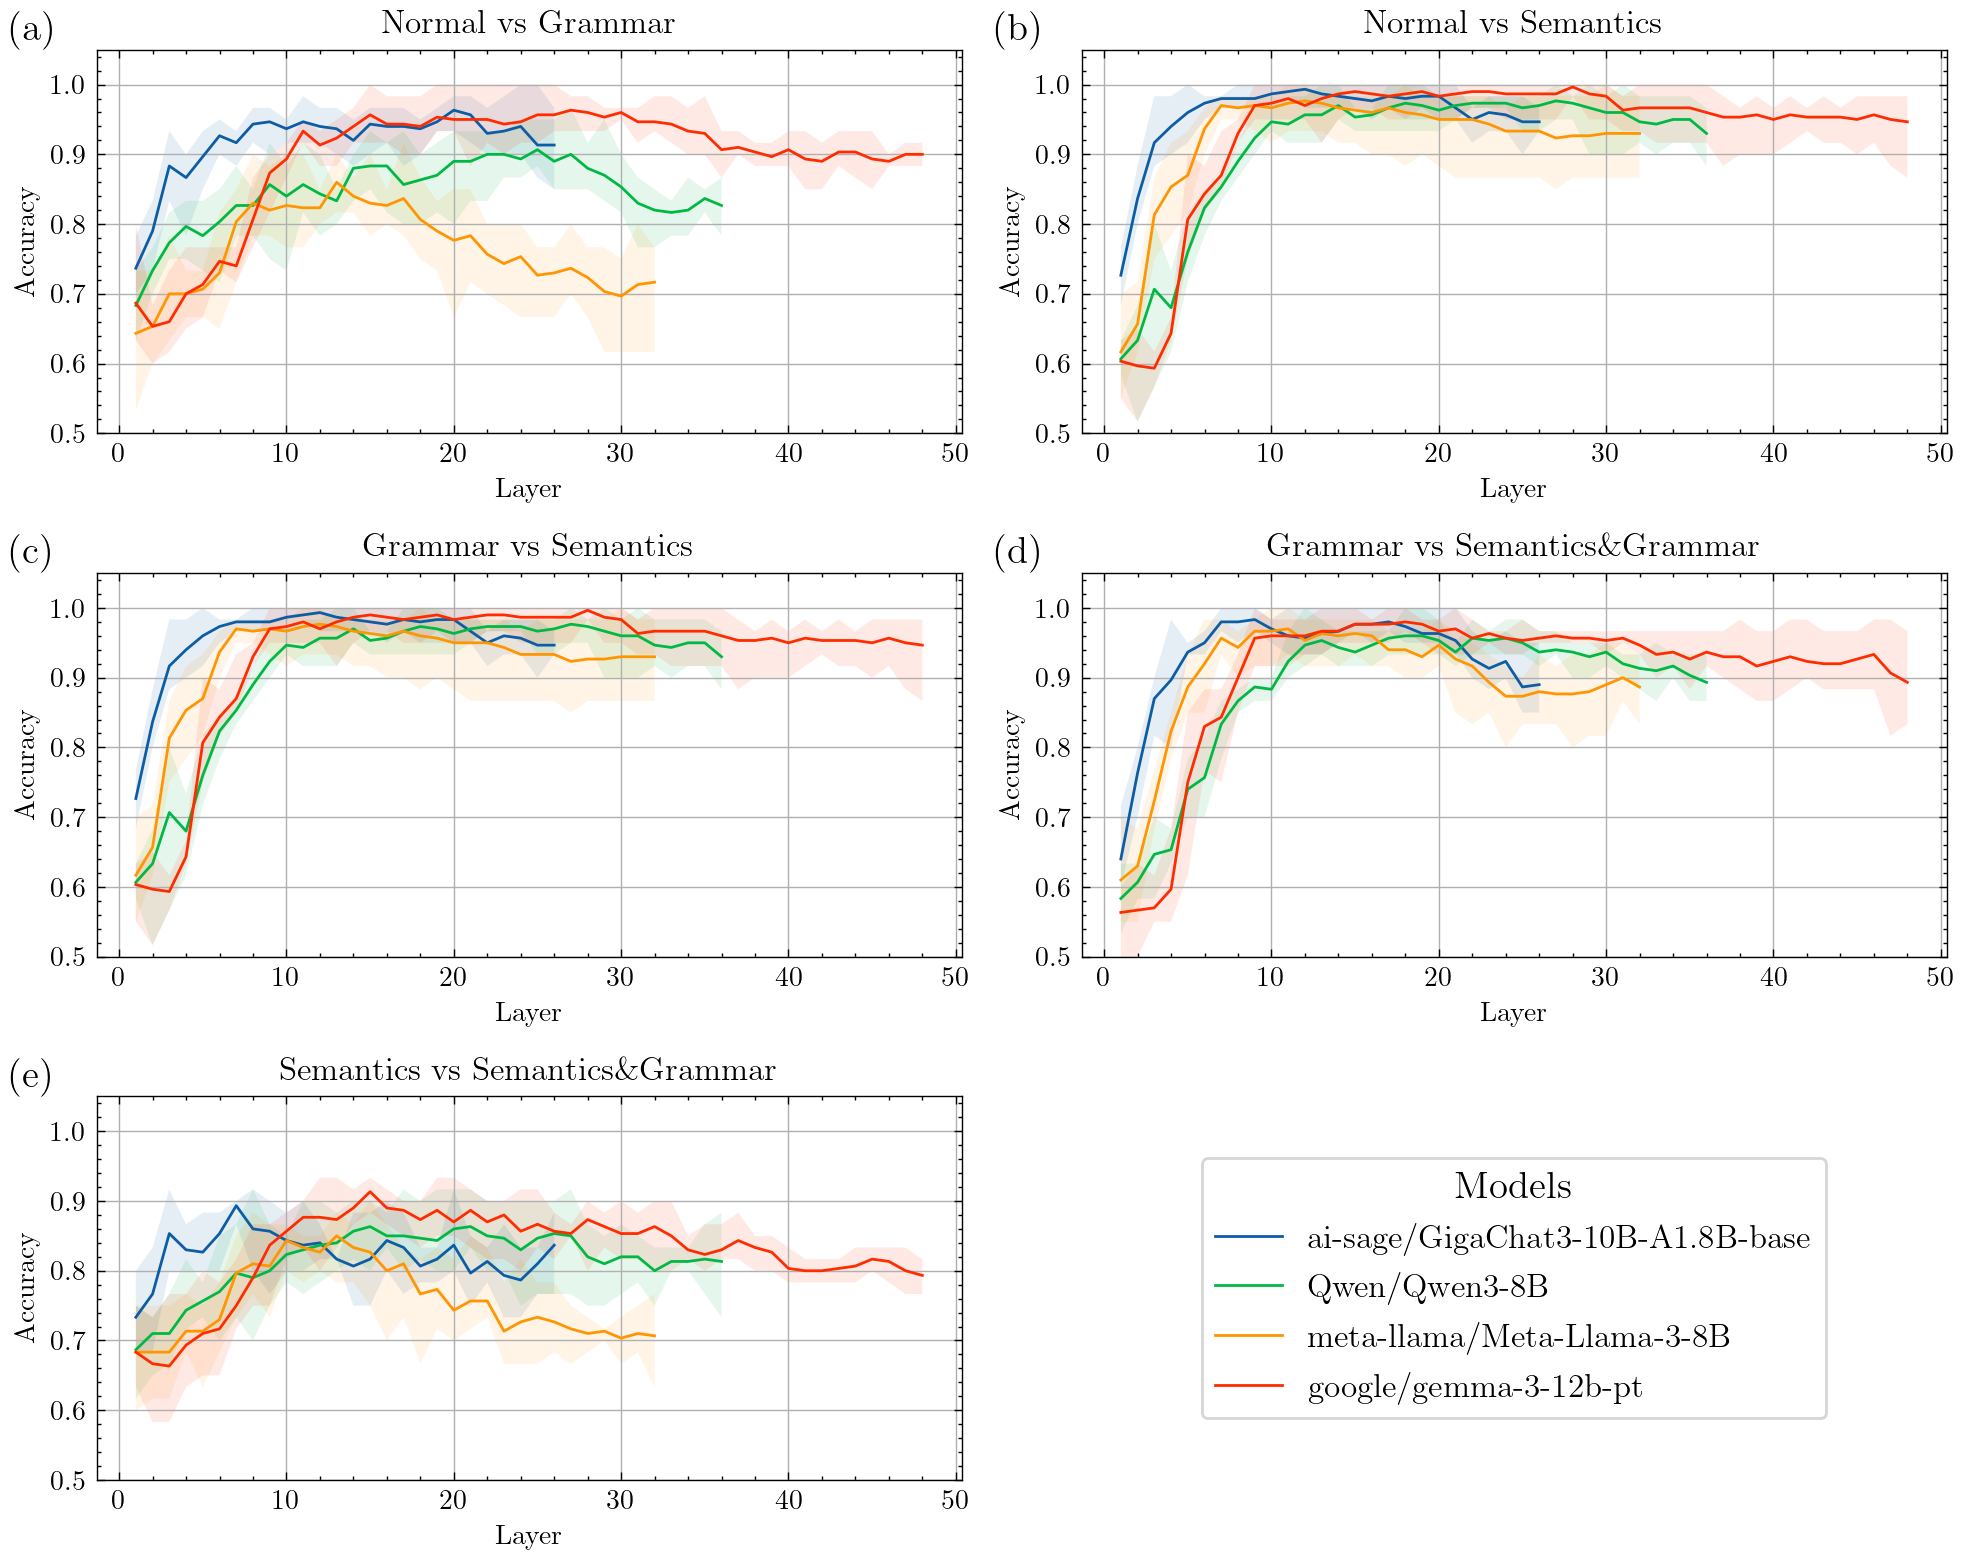

In [17]:
from matplotlib.axes._axes import Axes

def plot_accuracy(axes: Axes,
                  probing_results: dict,
                  title: str = "",
                  letter: str = ""):

    if not probing_results:
        return

    max_layers_len = 0
    for model, results in probing_results.items():
        all_layer_accs = probing_results[model]['all_layer_accs']

        layers = sorted(all_layer_accs.keys())[1:]

        if max_layers_len < len(layers):
            max_layers_len = len(layers)

        means = np.array([np.mean(all_layer_accs[l]) for l in layers])
        mins  = np.array([np.min(all_layer_accs[l]) for l in layers])
        maxs  = np.array([np.max(all_layer_accs[l]) for l in layers])

        axes.plot(layers, means, label=model)

        axes.fill_between(
            layers,
            mins,
            maxs,
            alpha=0.1,
        )

    axes.set_title(title)
    axes.grid(True)
    axes.set_ylabel("Accuracy")
    axes.set_xlabel("Layer")
    axes.set_ylim((0.5, 1.05))

    ax.text(
        -0.1, 1.1,
        f"({letter})",
        transform=axes.transAxes,
        fontsize=14,
        fontweight='bold',
        va='top'
    )

fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(10, 8))

axs = axs.flatten()

probing_results_sl = [
    norm_vs_grammar_probing_results_sl,
    norm_vs_semantic_probing_results_sl,
    grammar_vs_semantic_probing_results_sl,
    grammar_vs_semantic_grammar_probing_results_sl,
    semantics_vs_semantic_grammar_probing_results_sl,
    None
]

titles = [
    "Normal vs Grammar",
    "Normal vs Semantics",
    "Grammar vs Semantics",
    "Grammar vs Semantics\\&Grammar",
    "Semantics vs Semantics\\&Grammar",
    None
]

letters = [
    "a",
    "b",
    "c",
    "d",
    "e",
]

for i, (ax, probing_results, title, letter) in enumerate(zip(axs, probing_results_sl, titles, letters)):
    plot_accuracy(axes=ax,
                  probing_results=probing_results,
                  title=title,
                  letter=letter)

axs[-1].axis('off')

handles = []
labels = []
for ax in axs[:-1]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
handles, labels = zip(*unique) if unique else ([], [])

legend_ax = axs[-1]
legend_ax.legend(handles, labels,
                 loc='center',
                 frameon=True,
                 fancybox=True,
                 shadow=False,
                 fontsize=12,
                 title="Models",
                 title_fontsize=14)

plt.tight_layout()
plt.show()

### Word-level probing

In [ ]:


fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(10, 8))

axs = axs.flatten()

probing_results_sl = [
    norm_vs_grammar_probing_results_wl,
    norm_vs_semantic_probing_results_wl,
    grammar_vs_semantic_probing_results_wl,
    grammar_vs_semantic_grammar_probing_results_wl,
    semantics_vs_semantic_grammar_probing_results_wl,
    None
]

titles = [
    "Normal vs Grammar",
    "Normal vs Semantics",
    "Grammar vs Semantics",
    "Grammar vs Semantics\\&Grammar",
    "Semantics vs Semantics\\&Grammar",
    None
]

letters = [
    "a",
    "b",
    "c",
    "d",
    "e",
]

for i, (ax, probing_results, title, letter) in enumerate(zip(axs, probing_results_sl, titles, letters)):
    plot_accuracy(axes=ax,
                  probing_results=probing_results,
                  title=title,
                  letter=letter)

axs[-1].axis('off')

handles = []
labels = []
for ax in axs[:-1]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
handles, labels = zip(*unique) if unique else ([], [])

legend_ax = axs[-1]
legend_ax.legend(handles, labels,
                 loc='center',
                 frameon=True,
                 fancybox=True,
                 shadow=False,
                 fontsize=12,
                 title="Models",
                 title_fontsize=14)


plt.tight_layout()
plt.show()